In [ ]:
!pip install tensorflow
!pip install tf-keras-vis
!pip install kaggle
!pip install streamlit
!pip install pillow
!pip install matplotlib
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.1 MB/s eta 0:00:00


In [ ]:
# Step 1 - Upload kaggle.json from your PC
from google.colab import files
files.upload()  # A popup appears → select kaggle.json from your PC


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle setup done!")


✅ Kaggle setup done!


In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
print("✅ Download complete!")


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:51<00:00, 55.1MB/s]
100% 5.20G/5.20G [01:51<00:00, 49.9MB/s]
✅ Download complete!


In [ ]:
!unzip -q skin-cancer-mnist-ham10000.zip
!ls

app.py			HAM10000_metadata.csv  kaggle.json
ham10000_images_part_1	hmnist_28_28_L.csv     sample_data
HAM10000_images_part_1	hmnist_28_28_RGB.csv   skin-cancer-mnist-ham10000.zip
ham10000_images_part_2	hmnist_8_8_L.csv
HAM10000_images_part_2	hmnist_8_8_RGB.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image
import numpy as np

print("✅ Libraries imported!")


✅ Libraries imported!


In [ ]:
df = pd.read_csv('HAM10000_metadata.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())


Shape: (10015, 7)

First 5 rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [ ]:
print("Class distribution:")
print(df['dx'].value_counts())
print("\nPercentage:")
print(df['dx'].value_counts(normalize=True) * 100)


Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Percentage:
dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


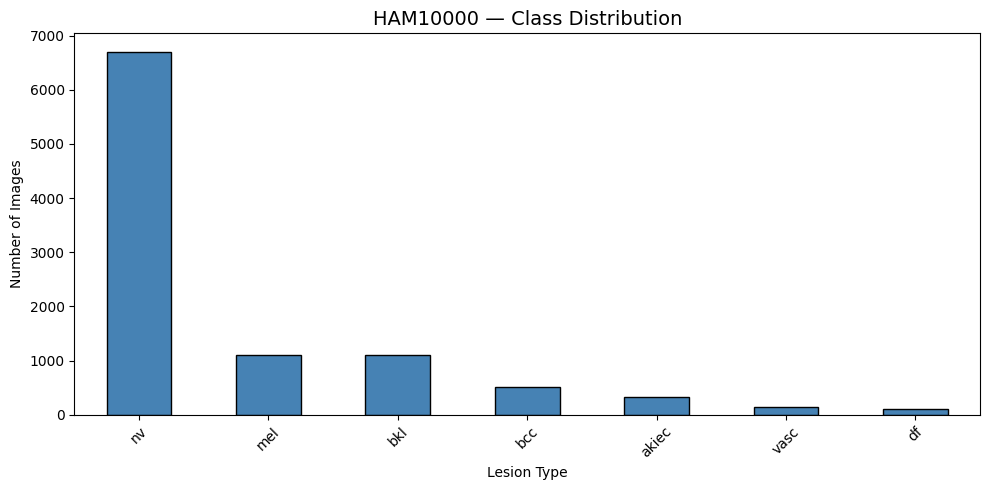

In [ ]:
plt.figure(figsize=(10, 5))
df['dx'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('HAM10000 — Class Distribution', fontsize=14)
plt.xlabel('Lesion Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Malignant: mel, bcc, akiec
# Benign: nv, bkl, df, vasc

df['label'] = df['dx'].apply(
    lambda x: 1 if x in ['mel', 'bcc', 'akiec'] else 0
)

print("Binary label distribution:")
print(df['label'].value_counts())
print("\n0 = Benign, 1 = Malignant")


Binary label distribution:
label
0    8061
1    1954
Name: count, dtype: int64

0 = Benign, 1 = Malignant


In [ ]:
# Combine both image folders into one dictionary
image_paths = {}

for folder in ['ham10000_images_part_1', 'ham10000_images_part_2']:
    for img in os.listdir(folder):
        img_id = img.replace('.jpg', '')
        image_paths[img_id] = os.path.join(folder, img)

print(f"Total images found: {len(image_paths)}")

# Add path column to dataframe
df['path'] = df['image_id'].map(image_paths)

# Check for missing paths
print(f"Missing paths: {df['path'].isna().sum()}")
print(df[['image_id', 'path', 'dx', 'label']].head())


Total images found: 10015
Missing paths: 0
       image_id                                     path   dx  label
0  ISIC_0027419  ham10000_images_part_1/ISIC_0027419.jpg  bkl      0
1  ISIC_0025030  ham10000_images_part_1/ISIC_0025030.jpg  bkl      0
2  ISIC_0026769  ham10000_images_part_1/ISIC_0026769.jpg  bkl      0
3  ISIC_0025661  ham10000_images_part_1/ISIC_0025661.jpg  bkl      0
4  ISIC_0031633  ham10000_images_part_2/ISIC_0031633.jpg  bkl      0


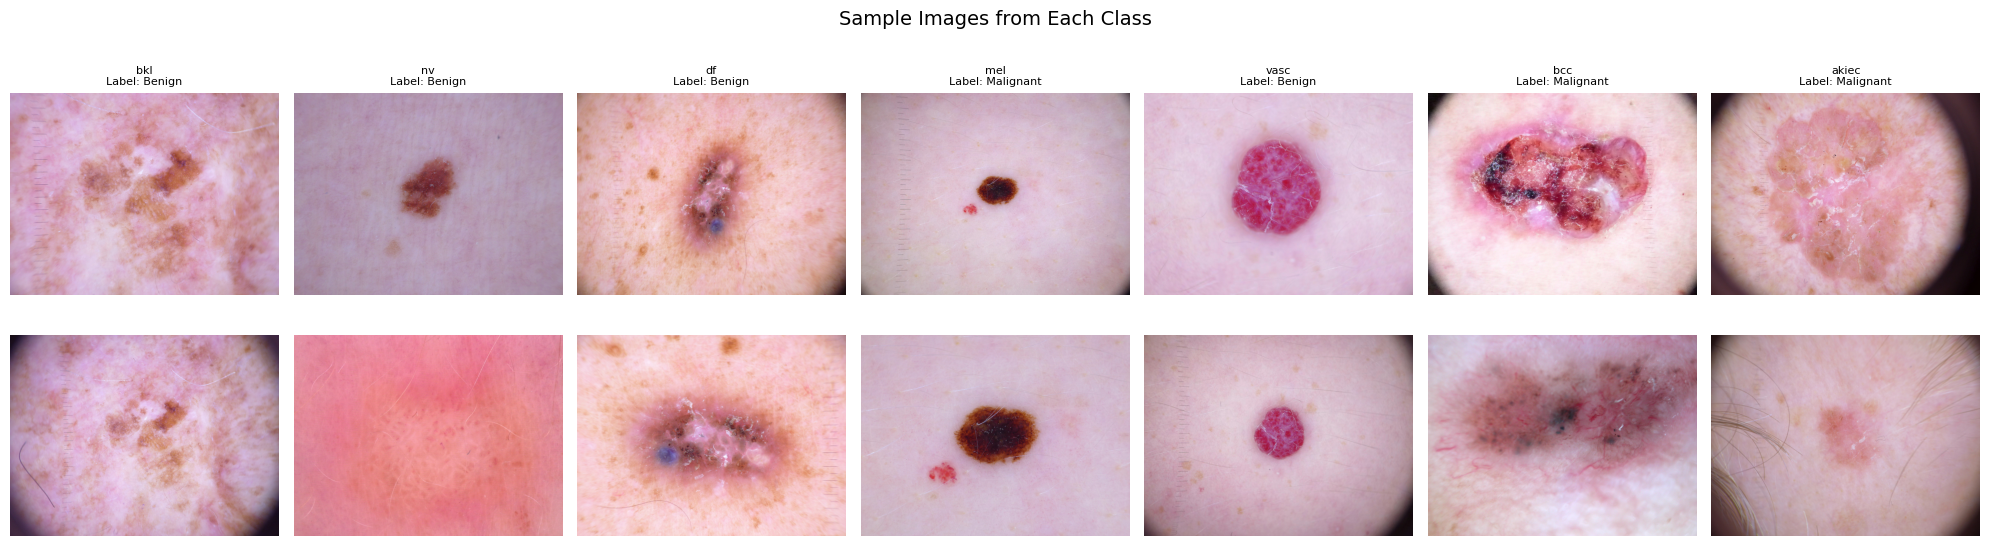

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
classes = df['dx'].unique()

for i, cls in enumerate(classes):
    # Benign sample
    sample = df[df['dx'] == cls].iloc[0]
    img = Image.open(sample['path'])
    axes[0][i].imshow(img)
    axes[0][i].set_title(f'{cls}\nLabel: {"Malignant" if sample["label"]==1 else "Benign"}',
                          fontsize=8)
    axes[0][i].axis('off')

    # Another sample
    sample2 = df[df['dx'] == cls].iloc[1]
    img2 = Image.open(sample2['path'])
    axes[1][i].imshow(img2)
    axes[1][i].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Save for use in next phases
df.to_csv('ham10000_cleaned.csv', index=False)
print("✅ Cleaned dataframe saved as ham10000_cleaned.csv!")
print(f"\nFinal dataset summary:")
print(f"Total images: {len(df)}")
print(f"Benign: {(df['label']==0).sum()}")
print(f"Malignant: {(df['label']==1).sum()}")


✅ Cleaned dataframe saved as ham10000_cleaned.csv!

Final dataset summary:
Total images: 10015
Benign: 8061
Malignant: 1954


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All libraries ready!")


✅ TensorFlow version: 2.19.0
✅ All libraries ready!


In [ ]:
df = pd.read_csv('ham10000_cleaned.csv')

# Convert label to string (required by ImageDataGenerator)
df['label'] = df['label'].astype(str)

print(f"Total samples: {len(df)}")
print(df['label'].value_counts())
print("✅ Data loaded!")


Total samples: 10015
label
0    8061
1    1954
Name: count, dtype: int64
✅ Data loaded!


In [ ]:
# Step 1: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Step 2: Split temp into 50/50 → 10% val, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"✅ Train samples   : {len(train_df)}")
print(f"✅ Validation samples: {len(val_df)}")
print(f"✅ Test samples    : {len(test_df)}")


✅ Train samples   : 8012
✅ Validation samples: 1001
✅ Test samples    : 1002


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

# Validation & Test generators — ONLY normalize
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")


✅ Data generators created!


In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("✅ All generators ready!")


Found 8012 validated image filenames belonging to 2 classes.
Found 1001 validated image filenames belonging to 2 classes.
Found 1002 validated image filenames belonging to 2 classes.
✅ All generators ready!


In [ ]:
# Get one batch and check shapes
images, labels = next(train_generator)

print(f"Image batch shape : {images.shape}")
print(f"Label batch shape : {labels.shape}")
print(f"Pixel value range : {images.min():.2f} to {images.max():.2f}")
print(f"Sample labels     : {labels[:5]}")


Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Pixel value range : 0.01 to 1.00
Sample labels     : [1. 0. 1. 0. 0.]


Found 1 validated image filenames.


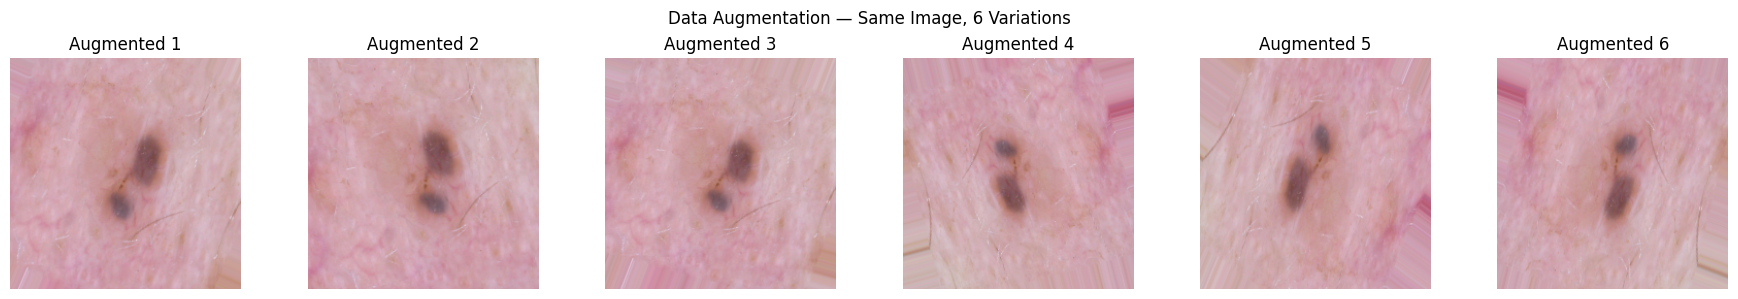

In [ ]:
# See how augmentation changes images
sample_df = train_df[train_df['label'] == '1'].head(1)

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)

aug_gen = aug_datagen.flow_from_dataframe(
    sample_df, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=1,
    class_mode='raw'    # ← Changed from 'binary' to 'raw'
)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i in range(6):
    img, _ = next(aug_gen)
    axes[i].imshow(img[0])
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation — Same Image, 6 Variations', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print("✅ Phase 4 Complete!")
print(f"Train : {len(train_df)} samples")
print(f"Val   : {len(val_df)} samples")
print(f"Test  : {len(test_df)} samples")
print("Ready for Phase 5 — Model Building! 🚀")


✅ Phase 4 Complete!
Train : 8012 samples
Val   : 1001 samples
Test  : 1002 samples
Ready for Phase 5 — Model Building! 🚀


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
import tensorflow as tf

print("✅ Libraries imported!")


✅ Libraries imported!


In [ ]:
# Load MobileNetV2 WITHOUT its top classifier
base_model = MobileNetV2(
    weights='imagenet',      # Pre-trained on ImageNet
    include_top=False,       # Remove final classification layer
    input_shape=(224, 224, 3)
)

# Freeze all base layers first
base_model.trainable = False

print(f"✅ MobileNetV2 loaded!")
print(f"Total layers in base model: {len(base_model.layers)}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 loaded!
Total layers in base model: 154


In [ ]:
# Build on top of MobileNetV2
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary output

# Final model
model = Model(inputs=base_model.input, outputs=output)

print("✅ Model architecture built!")
print(f"Total layers: {len(model.layers)}")
print(f"Total parameters: {model.count_params():,}")


✅ Model architecture built!
Total layers: 161
Total parameters: 2,624,065


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✅ Model compiled!")
model.summary()


✅ Model compiled!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
callbacks = [
    # Stop training if val_loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model automatically
    ModelCheckpoint(
        'derma_knight_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks ready!")


✅ Callbacks ready!


In [ ]:
print("🚀 Phase 1 Training — Top layers only...")
print("⏳ This will take about 10–15 minutes...\n")

history1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 1 Training Complete!")


🚀 Phase 1 Training — Top layers only...
⏳ This will take about 10–15 minutes...

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.7942 - auc: 0.7206 - loss: 0.5334 - precision: 0.4442 - recall: 0.3209
Epoch 1: val_accuracy improved from None to 0.82917, saving model to derma_knight_model.h5



Epoch 1: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 217s 775ms/step - accuracy: 0.7989 - auc: 0.7649 - loss: 0.4794 - precision: 0.4789 - recall: 0.3493 - val_accuracy: 0.8292 - val_auc: 0.8343 - val_loss: 0.3720 - val_precision: 0.6277 - val_recall: 0.3026 - learning_rate: 0.0010
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8093 - auc: 0.8096 - loss: 0.4107 - precision: 0.5237 - recall: 0.3733
Epoch 2: val_accuracy did not improve from 0.82917
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 600ms/step - accuracy: 0.8132 - auc: 0.8094 - loss: 0.4033 - precision: 0.5308 - recall: 0.3634 - val_accuracy: 0.8262 - val_auc: 0.8497 - val_loss: 0.3690 - val_precision: 0.5882 - val_recall: 0.3590 - learning_rate: 0.0010
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8325 - auc: 0.8441 - loss: 0.3696 - precision: 0.6180 - recall: 0.4231
Epoch 3: val_accuracy improved from 0.82917 to 0.83117, saving model to derma_knight_model.h5



Epoch 3: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 589ms/step - accuracy: 0.8305 - auc: 0.8380 - loss: 0.3721 - precision: 0.5988 - recall: 0.3973 - val_accuracy: 0.8312 - val_auc: 0.8425 - val_loss: 0.4005 - val_precision: 0.5774 - val_recall: 0.4974 - learning_rate: 0.0010
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8372 - auc: 0.8555 - loss: 0.3553 - precision: 0.6328 - recall: 0.4337
Epoch 4: val_accuracy did not improve from 0.83117
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 588ms/step - accuracy: 0.8400 - auc: 0.8538 - loss: 0.3538 - precision: 0.6365 - recall: 0.4191 - val_accuracy: 0.8222 - val_auc: 0.8408 - val_loss: 0.3841 - val_precision: 0.5914 - val_recall: 0.2821 - learning_rate: 0.0010
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.8372 - auc: 0.8573 - loss: 0.3543 - precision: 0.6319 - recall: 0.4161
Epoch 5: val_accuracy improved from 0.83117 to 0.83317, saving model to derma_knight_model.h5



Epoch 5: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.8389 - auc: 0.8556 - loss: 0.3537 - precision: 0.6355 - recall: 0.4082 - val_accuracy: 0.8332 - val_auc: 0.8544 - val_loss: 0.3575 - val_precision: 0.6296 - val_recall: 0.3487 - learning_rate: 0.0010
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.8415 - auc: 0.8544 - loss: 0.3524 - precision: 0.6349 - recall: 0.4247
Epoch 6: val_accuracy improved from 0.83317 to 0.84416, saving model to derma_knight_model.h5



Epoch 6: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 588ms/step - accuracy: 0.8405 - auc: 0.8606 - loss: 0.3486 - precision: 0.6396 - recall: 0.4178 - val_accuracy: 0.8442 - val_auc: 0.8597 - val_loss: 0.3534 - val_precision: 0.6512 - val_recall: 0.4308 - learning_rate: 0.0010
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.8400 - auc: 0.8579 - loss: 0.3472 - precision: 0.6319 - recall: 0.3921
Epoch 7: val_accuracy did not improve from 0.84416
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.8427 - auc: 0.8622 - loss: 0.3451 - precision: 0.6547 - recall: 0.4101 - val_accuracy: 0.8312 - val_auc: 0.8540 - val_loss: 0.3563 - val_precision: 0.6444 - val_recall: 0.2974 - learning_rate: 0.0010
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8503 - auc: 0.8756 - loss: 0.3247 - precision: 0.6566 - recall: 0.4163
Epoch 8: val_accuracy did not improve from 0.84416
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 593ms/step 


Epoch 9: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 595ms/step - accuracy: 0.8502 - auc: 0.8771 - loss: 0.3281 - precision: 0.6682 - recall: 0.4613 - val_accuracy: 0.8511 - val_auc: 0.8668 - val_loss: 0.3437 - val_precision: 0.6983 - val_recall: 0.4154 - learning_rate: 0.0010
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.8499 - auc: 0.8754 - loss: 0.3353 - precision: 0.6941 - recall: 0.4498
Epoch 10: val_accuracy did not improve from 0.85115
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 594ms/step - accuracy: 0.8510 - auc: 0.8743 - loss: 0.3316 - precision: 0.6804 - recall: 0.4453 - val_accuracy: 0.8452 - val_auc: 0.8624 - val_loss: 0.3460 - val_precision: 0.6724 - val_recall: 0.4000 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

✅ Phase 1 Training Complete!


In [ ]:
print("🔓 Unfreezing top 30 layers for fine-tuning...")

# Unfreeze top 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("🚀 Phase 2 Fine-tuning started...")
print("⏳ This will take about 15–20 minutes...\n")

history2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Phase 2 Fine-tuning Complete!")


🔓 Unfreezing top 30 layers for fine-tuning...
🚀 Phase 2 Fine-tuning started...
⏳ This will take about 15–20 minutes...

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.8244 - auc: 0.8291 - loss: 0.3796 - precision: 0.5792 - recall: 0.3589
Epoch 1: val_accuracy did not improve from 0.85115
251/251 ━━━━━━━━━━━━━━━━━━━━ 189s 669ms/step - accuracy: 0.8295 - auc: 0.8410 - loss: 0.3691 - precision: 0.5954 - recall: 0.3935 - val_accuracy: 0.8332 - val_auc: 0.8579 - val_loss: 0.4288 - val_precision: 0.7121 - val_recall: 0.2410 - learning_rate: 1.0000e-05
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8476 - auc: 0.8699 - loss: 0.3378 - precision: 0.6397 - recall: 0.4524
Epoch 2: val_accuracy did not improve from 0.85115
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 599ms/step - accuracy: 0.8424 - auc: 0.8625 - loss: 0.3481 - precision: 0.6404 - recall: 0.4376 - val_accuracy: 0.8352 - val_auc: 0.8609 - val_loss: 0.4064 - val_precision: 0.6974 - val_recall: 0.2718 - 


Epoch 5: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 602ms/step - accuracy: 0.8459 - auc: 0.8731 - loss: 0.3348 - precision: 0.6496 - recall: 0.4555 - val_accuracy: 0.8551 - val_auc: 0.8820 - val_loss: 0.3311 - val_precision: 0.7315 - val_recall: 0.4051 - learning_rate: 5.0000e-06
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8552 - auc: 0.8912 - loss: 0.3155 - precision: 0.6839 - recall: 0.4960
Epoch 6: val_accuracy improved from 0.85514 to 0.85814, saving model to derma_knight_model.h5



Epoch 6: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 594ms/step - accuracy: 0.8513 - auc: 0.8832 - loss: 0.3228 - precision: 0.6688 - recall: 0.4715 - val_accuracy: 0.8581 - val_auc: 0.8860 - val_loss: 0.3232 - val_precision: 0.7227 - val_recall: 0.4410 - learning_rate: 5.0000e-06
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8493 - auc: 0.8834 - loss: 0.3230 - precision: 0.6759 - recall: 0.4618
Epoch 7: val_accuracy improved from 0.85814 to 0.86014, saving model to derma_knight_model.h5



Epoch 7: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 601ms/step - accuracy: 0.8522 - auc: 0.8837 - loss: 0.3214 - precision: 0.6727 - recall: 0.4722 - val_accuracy: 0.8601 - val_auc: 0.8880 - val_loss: 0.3210 - val_precision: 0.7434 - val_recall: 0.4308 - learning_rate: 5.0000e-06
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8499 - auc: 0.8835 - loss: 0.3244 - precision: 0.6755 - recall: 0.4685
Epoch 8: val_accuracy improved from 0.86014 to 0.86114, saving model to derma_knight_model.h5



Epoch 8: finished saving model to derma_knight_model.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 600ms/step - accuracy: 0.8545 - auc: 0.8836 - loss: 0.3223 - precision: 0.6793 - recall: 0.4811 - val_accuracy: 0.8611 - val_auc: 0.8905 - val_loss: 0.3178 - val_precision: 0.7545 - val_recall: 0.4256 - learning_rate: 5.0000e-06
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.8567 - auc: 0.8886 - loss: 0.3195 - precision: 0.6742 - recall: 0.5128
Epoch 9: val_accuracy did not improve from 0.86114
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 592ms/step - accuracy: 0.8575 - auc: 0.8877 - loss: 0.3187 - precision: 0.6835 - recall: 0.5016 - val_accuracy: 0.8591 - val_auc: 0.8899 - val_loss: 0.3178 - val_precision: 0.7647 - val_recall: 0.4000 - learning_rate: 5.0000e-06
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.8631 - auc: 0.8906 - loss: 0.3131 - precision: 0.6989 - recall: 0.5112
Epoch 10: val_accuracy did not improve from 0.86114
251/251 ━━━━━━━━━━━━━━━━━━━━ 153s 6

In [ ]:
# Combine both training histories
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Val Accuracy', color='orange')
plt.axvline(x=len(history1.history['accuracy']),
            color='red', linestyle='--', label='Fine-tune start')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Val Loss', color='orange')
plt.axvline(x=len(history1.history['loss']),
            color='red', linestyle='--', label='Fine-tune start')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
print("📊 Evaluating on test set...")

results = model.evaluate(test_generator, verbose=1)

print(f"\n✅ Test Results:")
print(f"   Loss      : {results[0]:.4f}")
print(f"   Accuracy  : {results[1]*100:.2f}%")
print(f"   AUC       : {results[2]*100:.2f}%")
print(f"   Precision : {results[3]*100:.2f}%")
print(f"   Recall    : {results[4]*100:.2f}%")


📊 Evaluating on test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 461ms/step - accuracy: 0.8473 - auc: 0.8864 - loss: 0.3189 - precision: 0.6807 - recall: 0.4133

✅ Test Results:
   Loss      : 0.3189
   Accuracy  : 84.73%
   AUC       : 88.64%
   Precision : 68.07%
   Recall    : 41.33%


In [ ]:
model.save('derma_knight_model.h5')
print("✅ Model saved as derma_knight_model.h5!")

# Download to your PC
from google.colab import files
files.download('derma_knight_model.h5')
print("✅ Model downloaded to your PC!")


In [ ]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import load_model

print("✅ Libraries imported!")


In [ ]:
model = load_model('derma_knight_model.h5')
print("✅ Model loaded successfully!")
print(f"Model input shape: {model.input_shape}")


✅ Model loaded successfully!
Model input shape: (None, 224, 224, 3)


In [ ]:
# Find the last convolutional layer name
for layer in reversed(model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer = layer.name
        print(f"✅ Last Conv Layer: {last_conv_layer}")
        break


✅ Last Conv Layer: Conv_1_bn


In [ ]:
def generate_gradcam(img_path, model, last_conv_layer):
    """
    Generate Grad-CAM heatmap for a given image
    Returns: original image, heatmap overlay, prediction, confidence
    """
    # Step 1 — Load & preprocess image
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array_normalized = np.expand_dims(img_array / 255.0, axis=0)

    # Step 2 — Create gradient model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.output
        ]
    )

    # Step 3 — Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array_normalized)
        loss = predictions[:, 0]

    # Step 4 — Get gradients of output w.r.t conv layer
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Step 5 — Weight the conv outputs
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    # Step 6 — Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap = heatmap / heatmap.max()

    # Step 7 — Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (224, 224))

    # Step 8 — Apply color map (JET = blue→green→red)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    # Step 9 — Overlay heatmap on original image
    original_img = np.uint8(img_array)
    original_bgr = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)
    superimposed = cv2.addWeighted(
        original_bgr, 0.6,
        heatmap_colored, 0.4,
        0
    )
    superimposed_rgb = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

    # Step 10 — Get prediction details
    confidence = float(predictions[0][0])
    prediction = "Malignant" if confidence > 0.5 else "Benign"
    confidence_pct = confidence if confidence > 0.5 else 1 - confidence

    return img_array/255.0, superimposed_rgb, prediction, confidence_pct

print("✅ Grad-CAM function ready!")


✅ Grad-CAM function ready!


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


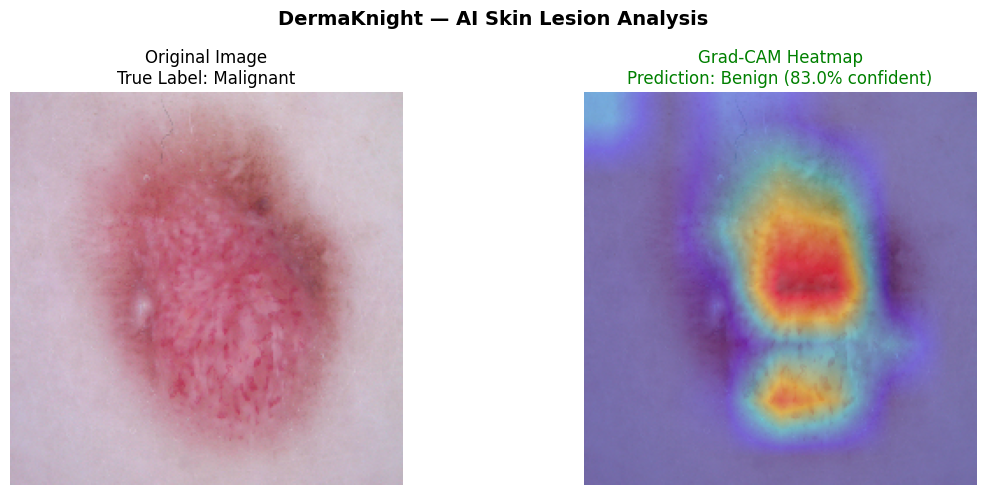


📊 Result:
   True Label  : Malignant
   Prediction  : Benign
   Confidence  : 83.0%


In [ ]:
# Pick one test image
sample = test_df.iloc[0]
img_path = sample['path']
true_label = "Malignant" if sample['label'] == '1' else "Benign"

# Generate Grad-CAM
original, heatmap_overlay, prediction, confidence = generate_gradcam(
    img_path, model, last_conv_layer
)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
axes[0].imshow(original)
axes[0].set_title(f'Original Image\nTrue Label: {true_label}', fontsize=12)
axes[0].axis('off')

# Grad-CAM heatmap
axes[1].imshow(heatmap_overlay)
axes[1].set_title(
    f'Grad-CAM Heatmap\nPrediction: {prediction} ({confidence*100:.1f}% confident)',
    fontsize=12,
    color='red' if prediction == 'Malignant' else 'green'
)
axes[1].axis('off')

plt.suptitle('DermaKnight — AI Skin Lesion Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Result:")
print(f"   True Label  : {true_label}")
print(f"   Prediction  : {prediction}")
print(f"   Confidence  : {confidence*100:.1f}%")


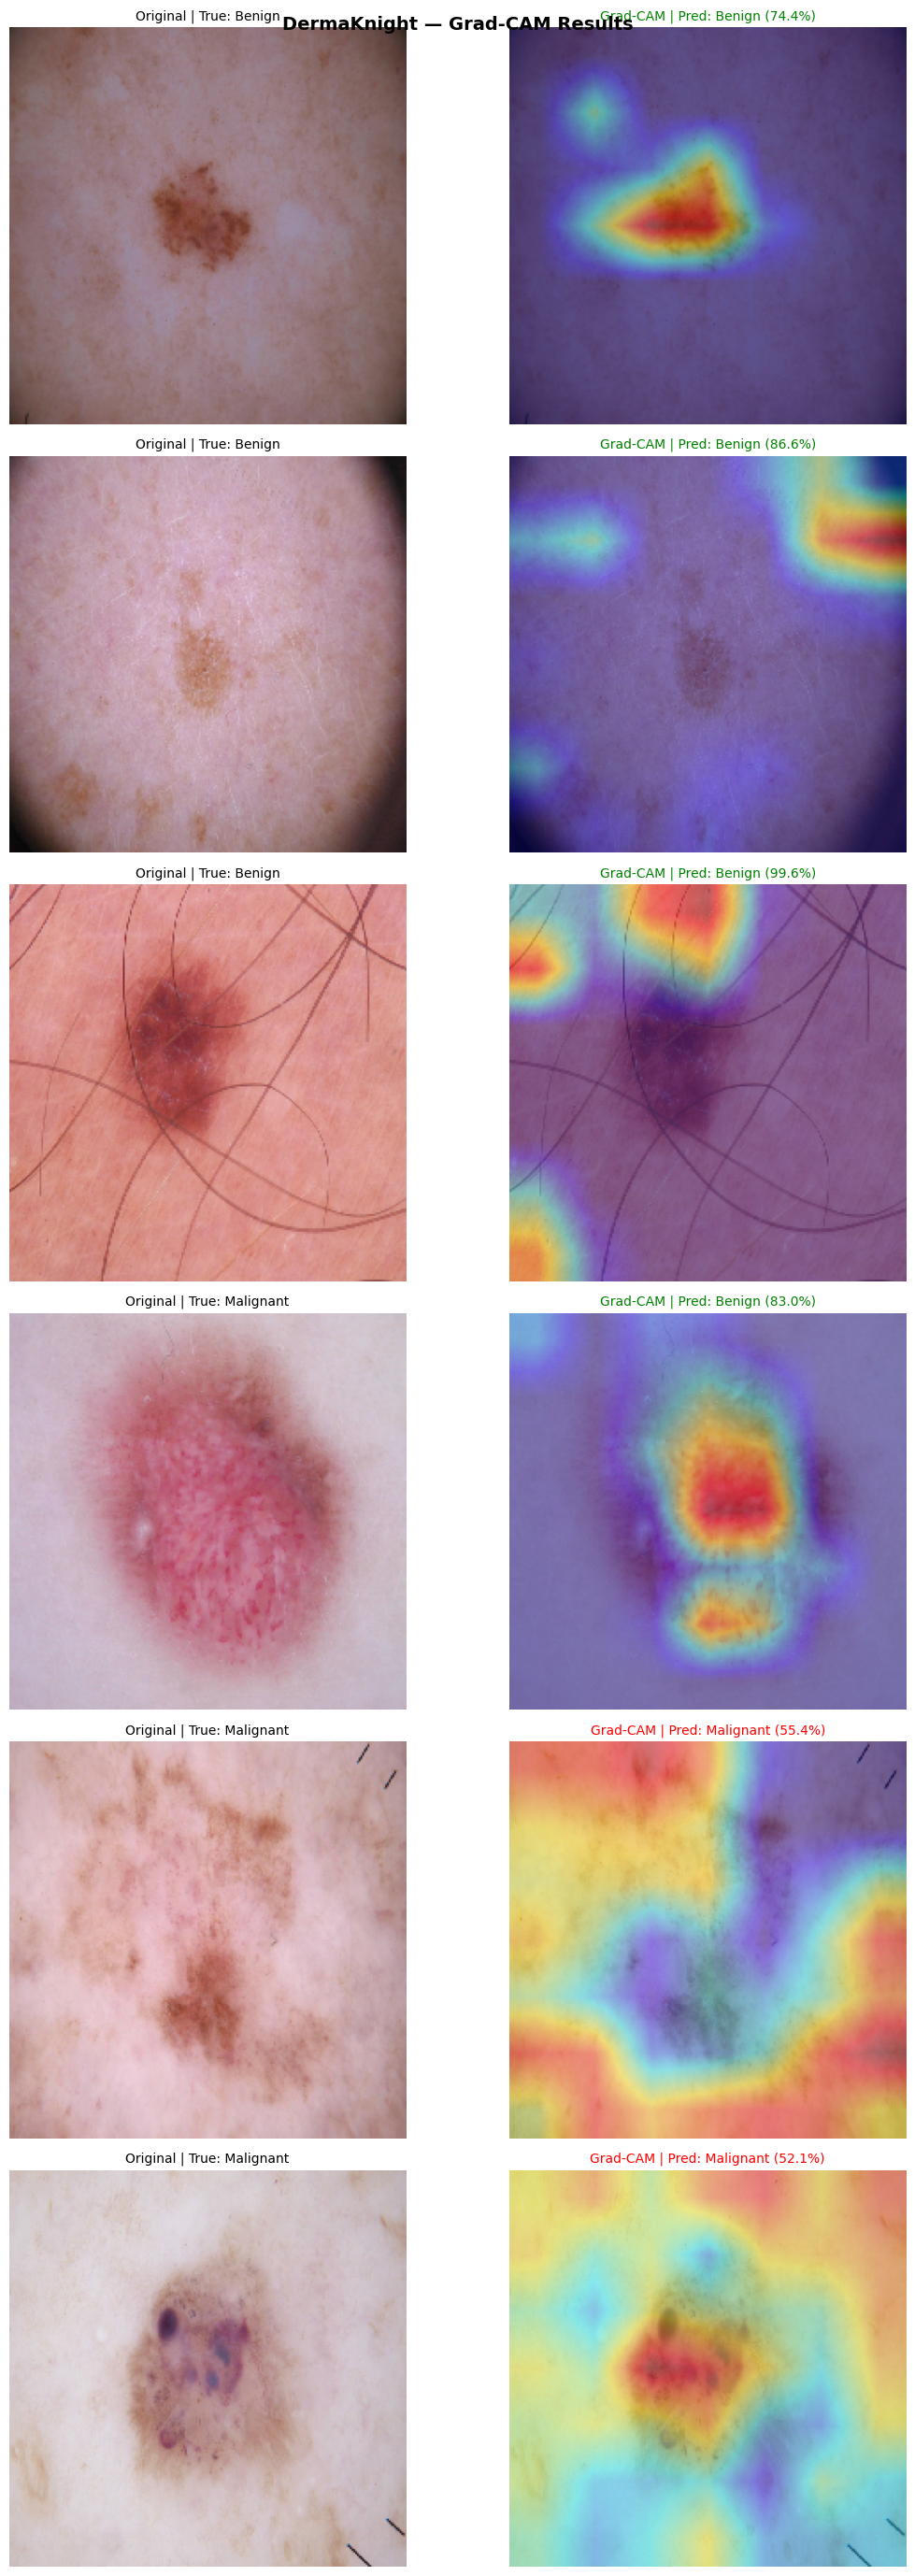

In [ ]:
# Test on 6 images — 3 benign + 3 malignant
benign_samples = test_df[test_df['label'] == '0'].head(3)
malignant_samples = test_df[test_df['label'] == '1'].head(3)
samples = pd.concat([benign_samples, malignant_samples])

fig, axes = plt.subplots(6, 2, figsize=(12, 28))

for idx, (_, row) in enumerate(samples.iterrows()):
    img_path = row['path']
    true_label = "Malignant" if row['label'] == '1' else "Benign"

    original, heatmap_overlay, prediction, confidence = generate_gradcam(
        img_path, model, last_conv_layer
    )

    # Original
    axes[idx][0].imshow(original)
    axes[idx][0].set_title(f'Original | True: {true_label}', fontsize=10)
    axes[idx][0].axis('off')

    # Heatmap
    color = 'red' if prediction == 'Malignant' else 'green'
    axes[idx][1].imshow(heatmap_overlay)
    axes[idx][1].set_title(
        f'Grad-CAM | Pred: {prediction} ({confidence*100:.1f}%)',
        fontsize=10, color=color
    )
    axes[idx][1].axis('off')

plt.suptitle('DermaKnight — Grad-CAM Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


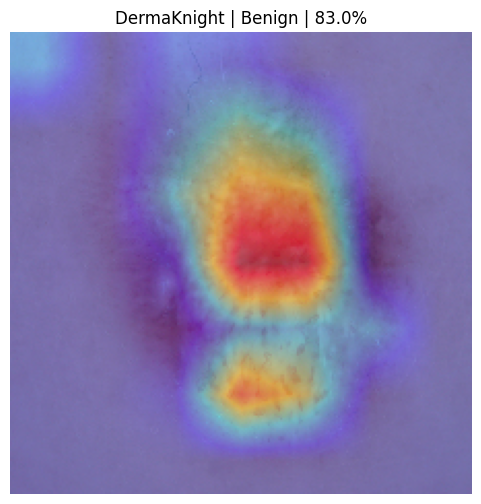

✅ Demo image saved as demo_gradcam_result.png!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save one good demo result for your presentation
sample = test_df[test_df['label'] == '1'].iloc[0]  # Malignant sample

original, heatmap_overlay, prediction, confidence = generate_gradcam(
    sample['path'], model, last_conv_layer
)

# Save heatmap image
plt.figure(figsize=(6, 6))
plt.imshow(heatmap_overlay)
plt.title(f'DermaKnight | {prediction} | {confidence*100:.1f}%', fontsize=12)
plt.axis('off')
plt.savefig('demo_gradcam_result.png', bbox_inches='tight', dpi=150)
plt.show()

print("✅ Demo image saved as demo_gradcam_result.png!")

# Download it
from google.colab import files
files.download('demo_gradcam_result.png')


In [ ]:
!pip install streamlit -q
!pip install pyngrok -q
print("✅ Streamlit installed!")


✅ Streamlit installed!


In [ ]:
app_code = '''
import streamlit as st
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image
from PIL import Image
import io

# ─── Page Config ───────────────────────────────────────────
st.set_page_config(
    page_title="DermaKnight",
    page_icon="🩺",
    layout="wide"
)

# ─── Header ────────────────────────────────────────────────
st.markdown("""
<h1 style='text-align:center; color:#E63946;'>
    🩺 DermaKnight
</h1>
<h4 style='text-align:center; color:#457B9D;'>
    AI-Powered Skin Cancer Detection Assistant
</h4>
<hr>
""", unsafe_allow_html=True)

# ─── Load Model ────────────────────────────────────────────
@st.cache_resource
def load_derma_model():
    model = load_model('derma_knight_model.h5')
    return model

model = load_derma_model()

# Find last conv layer
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if "conv" in layer.name.lower():
            return layer.name
    return None

last_conv_layer = get_last_conv_layer(model)

# ─── Grad-CAM Function ─────────────────────────────────────
def generate_gradcam(img_array, model, last_conv_layer):
    img_normalized = np.expand_dims(img_array / 255.0, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_normalized)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap = heatmap / heatmap.max()

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )

    original_bgr = cv2.cvtColor(np.uint8(img_array), cv2.COLOR_RGB2BGR)
    superimposed = cv2.addWeighted(original_bgr, 0.6, heatmap_colored, 0.4, 0)
    superimposed_rgb = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

    confidence = float(predictions[0][0])
    prediction = "Malignant" if confidence > 0.5 else "Benign"
    confidence_pct = confidence if confidence > 0.5 else 1 - confidence

    return superimposed_rgb, prediction, confidence_pct

# ─── Sidebar ───────────────────────────────────────────────
with st.sidebar:
    st.image("https://i.imgur.com/4M7IWwP.png", width=80)
    st.markdown("### About DermaKnight")
    st.info("""
    DermaKnight uses deep learning (MobileNetV2 + Grad-CAM)
    to classify skin lesions as **Benign** or **Malignant**.

    **Dataset:** HAM10000
    **Model:** MobileNetV2 (Transfer Learning)
    **Explainability:** Grad-CAM Heatmap
    """)
    st.markdown("### How to Use")
    st.markdown("""
    1. Upload a dermoscopic image
    2. Click **Analyze**
    3. View prediction + heatmap
    4. Consult a dermatologist
    """)
    st.warning("⚠️ For clinical support only. Not a replacement for professional diagnosis.")

# ─── Main Content ──────────────────────────────────────────
col1, col2 = st.columns(2)

with col1:
    st.markdown("### 📤 Upload Skin Lesion Image")
    uploaded_file = st.file_uploader(
        "Choose a dermoscopic image (JPG/PNG)",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_file:
        img = Image.open(uploaded_file).convert("RGB")
        img_resized = img.resize((224, 224))
        img_array = np.array(img_resized)

        st.image(img, caption="Uploaded Image", use_column_width=True)

        analyze_btn = st.button("🔬 Analyze Image", type="primary")

with col2:
    st.markdown("### 📊 Analysis Results")

    if uploaded_file and analyze_btn:
        with st.spinner("🔍 Analyzing... Please wait..."):
            heatmap_img, prediction, confidence = generate_gradcam(
                img_array, model, last_conv_layer
            )

        # Show result
        if prediction == "Malignant":
            st.error(f"⚠️ Prediction: **{prediction}**")
            st.markdown(f"### 🔴 MALIGNANT")
        else:
            st.success(f"✅ Prediction: **{prediction}**")
            st.markdown(f"### 🟢 BENIGN")

        # Confidence bar
        st.markdown(f"**Confidence: {confidence*100:.1f}%**")
        st.progress(float(confidence))

        # Heatmap
        st.markdown("### 🌡️ Grad-CAM Heatmap")
        st.image(heatmap_img, caption="Red = High suspicion region", use_column_width=True)

        # Heatmap legend
        st.markdown("""
        | Color | Meaning |
        |-------|---------|
        | 🔴 Red | Highest suspicion |
        | 🟡 Yellow | Medium attention |
        | 🔵 Blue | Low attention |
        """)

        # Disclaimer
        st.markdown("---")
        st.warning("""
        ⚠️ **Medical Disclaimer:**
        DermaKnight is a clinical decision-support tool designed
        for healthcare professionals. This result is NOT a medical
        diagnosis. Always consult a qualified dermatologist for
        definitive diagnosis and treatment.
        """)

    elif not uploaded_file:
        st.info("👈 Upload an image on the left to begin analysis")

# ─── Footer ────────────────────────────────────────────────
st.markdown("---")
st.markdown("""
<p style='text-align:center; color:gray;'>
    DermaKnight | Built for Hack Hustle: Code Knight 2026 |
    Saveetha Engineering College | HealthTech Domain
</p>
""", unsafe_allow_html=True)
'''

# Write to file
with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py created successfully!")


In [ ]:
from pyngrok import ngrok

# Paste your token here
ngrok.set_auth_token("35tEIcamq2Ys2ZKjr4UbZREtHTr_65WMDZqvNiphE4nDmq5eJ")
print("✅ ngrok authenticated!")


In [ ]:
import subprocess
import threading
import time

ngrok.kill()

def run_streamlit():
    subprocess.run(['streamlit', 'run', 'app.py',
                   '--server.port', '8501',
                   '--server.headless', 'true'])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

time.sleep(5)

public_url = ngrok.connect(8501)
print("=" * 50)
print(f"✅ DermaKnight is LIVE!")
print(f"🌐 Open this URL: {public_url}")
print("=" * 50)


In [ ]:
# Run this in Colab to save some test images
import shutil
import pandas as pd

df = pd.read_csv('ham10000_cleaned.csv')

# Save 3 benign + 3 malignant test images
benign = df[df['label'] == 0].head(3)
malignant = df[df['label'] == 1].head(3)

for i, row in benign.iterrows():
    shutil.copy(row['path'], f'test_benign_{i}.jpg')

for i, row in malignant.iterrows():
    shutil.copy(row['path'], f'test_malignant_{i}.jpg')

# Download all to your PC
from google.colab import files
for i, row in benign.iterrows():
    files.download(f'test_benign_{i}.jpg')
for i, row in malignant.iterrows():
    files.download(f'test_malignant_{i}.jpg')

print("✅ Test images downloaded!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Test images downloaded!


Found 1002 validated image filenames belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 615ms/step
📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.87      0.95      0.91       806
   Malignant       0.68      0.41      0.51       196

    accuracy                           0.85      1002
   macro avg       0.78      0.68      0.71      1002
weighted avg       0.83      0.85      0.83      1002



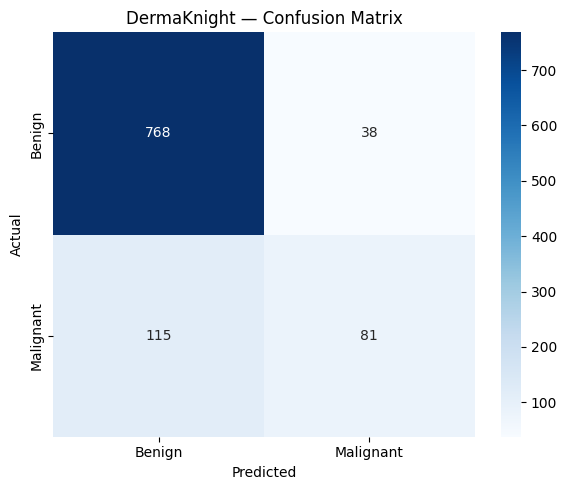

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

test_df = pd.read_csv('test_split.csv')

# ✅ Fix — Convert label to string
test_df['label'] = test_df['label'].astype(str)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Predictions
y_pred_proba = model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# ✅ Fix — Convert back to int for metrics
y_true = test_df['label'].astype(int).values

# Classification Report
print("📊 Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=['Benign', 'Malignant']
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('DermaKnight — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
